(np.float64(-0.5), np.float64(780.5), np.float64(811.5), np.float64(-0.5))

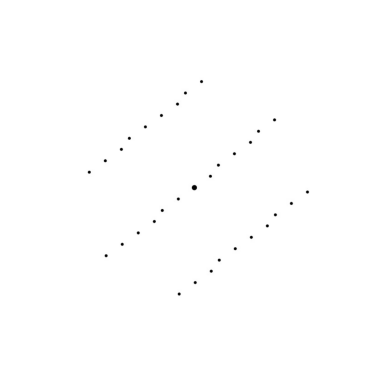

In [1]:
import cv2
import matplotlib.pyplot as plt

zonal_path = "/home/evgeny/gitlab/geometric-diffraction-analysis/data/500/cell_1/DIFF_Fibonaci_CELL_3.5784_10.5383_17.1131_116.8042_103.9746_106.8257__WL_0.0251_ExcErr_0.01_RES_1_ori_-0.8108_0.55861_-0.17483.jpg"

zonal_img = cv2.imread(zonal_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(zonal_img, cmap='gray')
plt.axis('off')

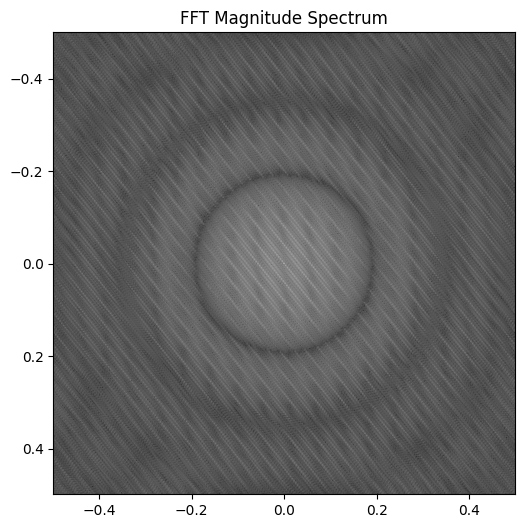

In [2]:
import numpy as np

# Perform FFT
zonal_f = np.fft.fft2(zonal_img)
zonal_fshift = np.fft.fftshift(zonal_f)
zonal_magnitude_spectrum = 20 * np.log(np.abs(zonal_fshift) + 1)

rows, cols = zonal_img.shape
crow, ccol = rows // 2, cols // 2
freq_y = np.fft.fftshift(np.fft.fftfreq(rows))
freq_x = np.fft.fftshift(np.fft.fftfreq(cols))
extent = [freq_x[0], freq_x[-1], freq_y[-1], freq_y[0]]

# Display the magnitude spectrum
plt.figure(figsize=(8, 6))
plt.imshow(zonal_magnitude_spectrum, cmap='gray', extent=extent)
plt.title('FFT Magnitude Spectrum')
# plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(780.5), np.float64(811.5), np.float64(-0.5))

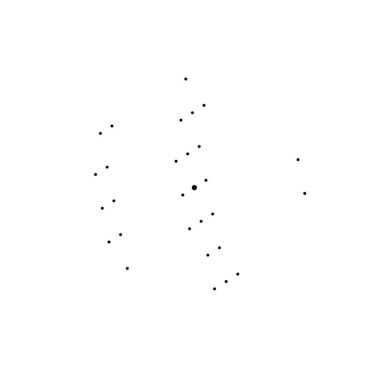

In [3]:
laue_path = '/home/evgeny/gitlab/geometric-diffraction-analysis/data/500/cell_1/DIFF_Fibonaci_CELL_3.5784_10.5383_17.1131_116.8042_103.9746_106.8257__WL_0.0251_ExcErr_0.01_RES_1_ori_-0.1787_0.16464_-0.97003.jpg'
laue_img = cv2.imread(laue_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(laue_img, cmap='gray')
plt.axis('off')

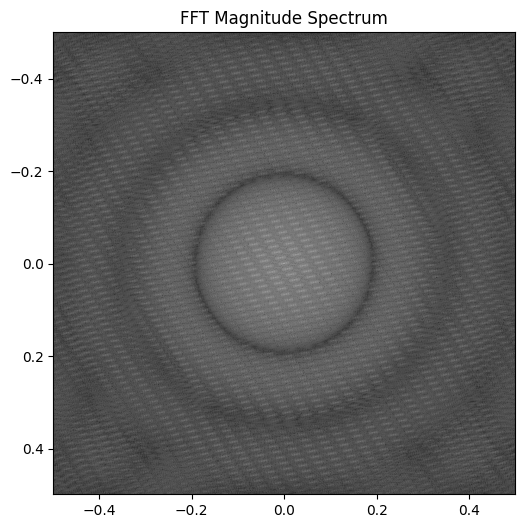

In [4]:
# Perform FFT
laue_f = np.fft.fft2(laue_img)
laue_fshift = np.fft.fftshift(laue_f)
laue_magnitude_spectrum = 20 * np.log(np.abs(laue_fshift) + 1)

rows, cols = laue_img.shape
crow, ccol = rows // 2, cols // 2
freq_y = np.fft.fftshift(np.fft.fftfreq(rows))
freq_x = np.fft.fftshift(np.fft.fftfreq(cols))
extent = [freq_x[0], freq_x[-1], freq_y[-1], freq_y[0]]

# Display the magnitude spectrum
plt.figure(figsize=(8, 6))
plt.imshow(laue_magnitude_spectrum, cmap='gray', extent=extent)
plt.title('FFT Magnitude Spectrum')
# plt.axis('off')
plt.show()

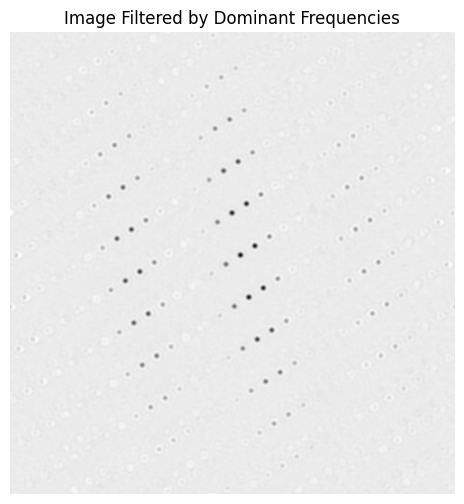

In [6]:
# Set a threshold for the magnitude spectrum
threshold = 220  # You can adjust this value as needed

# Create a mask where magnitude is above the threshold
mask = laue_magnitude_spectrum > threshold

# Apply the mask to the shifted FFT
fshift_filtered = laue_fshift * mask

# Inverse FFT to reconstruct the filtered image
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Display the filtered image
plt.figure(figsize=(8, 6))
plt.imshow(img_filtered, cmap='gray')
plt.title('Image Filtered by Dominant Frequencies')
plt.axis('off')
plt.show()

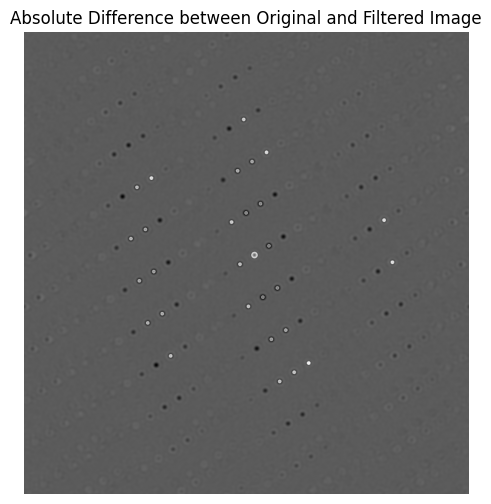

In [ ]:
# Display the filtered image
plt.figure(figsize=(8, 6))
plt.imshow(img_filtered-laue_img, cmap='gray')
plt.title('Absolute Difference between Original and Filtered Image')
plt.axis('off')
plt.show()

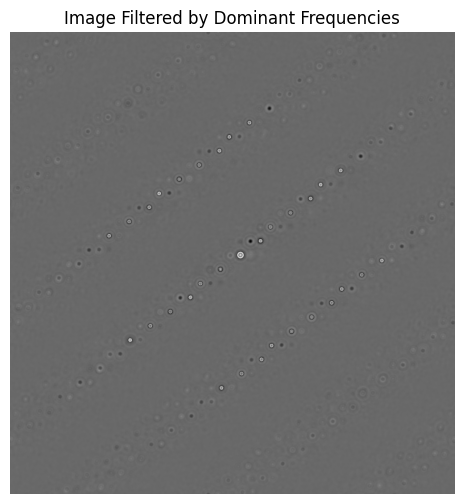

In [11]:
# Set a threshold for the magnitude spectrum
threshold = 200  # You can adjust this value as needed

# Create a mask where magnitude is above the threshold
mask = zonal_magnitude_spectrum > threshold

# Apply the mask to the shifted FFT
fshift_filtered = zonal_fshift * mask

# Inverse FFT to reconstruct the filtered image
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Display the filtered image
plt.figure(figsize=(8, 6))
plt.imshow(img_filtered - zonal_img, cmap='gray')
plt.title('Image Filtered by Dominant Frequencies')
plt.axis('off')
plt.show()